# Logistics Considerations: Route Permutations y Kilómetros en Vacío (Análisis Profesional)

Este cuaderno presenta un análisis exhaustivo *Profesional* sobre la **complejidad combinatoria** del ruteo logístico y el impacto de los **kilómetros en vacío** (Empty Kilometers).

Aquí aislamos el problema estructural: solo consideramos el transporte pesado Inter-Plantas, excluyendo a los clientes finales (Customer drop-offs). Esto evalúa la eficiencia de la troncal principal (Depósito ↔ Plantas de Cartón).

## Objetivos
1. Demostrar la crecimiento combinatorio matemática (permutaciones viables) según el número de paradas.
2. Modelar y distribuir los Kilómetros en Vacío (retorno estricto a base).
3. Generar visualizaciones para el análisis de operaciones logísticas.

---
*Desarrollado para la optimización GABM Logistics.*

In [15]:
import json
import math
import itertools
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Asegurarnos de alcanzar los módulos src locales
ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR
from src.utils.geo import GeoUtils

# Estilo global Profesional para Seaborn
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({'font.family': 'sans-serif', 'figure.facecolor': 'white'})

--- 
## 1. Carga Inteligente de Nodos Estratégicos
Solo nos interesa el `depot` original y las `carton_plants`.

In [16]:
plants_file = DATA_DIR / 'locations_smurfit.json'

with open(plants_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Inicializamos nodos estrictamente core
core_nodes = []
core_nodes.append({**data['paper_plant'], "id": "DEPOT", "type": "depot", "matrix_idx": 0})

idx = 1
for p in data['carton_plants']:
    # Removemos el diccionario anidado de clientes si existe, para limpiar memoria
    clean_node = {k: v for k, v in p.items() if k != 'customers'}
    core_nodes.append({**clean_node, "type": "carton_plant", "matrix_idx": idx})
    idx += 1

df_nodes = pd.DataFrame(core_nodes)
display(df_nodes[['id', 'name', 'type', 'lat', 'lng']].style.set_properties(**{'background-color': '#f8f9fa'}).set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}]))

,id,name,type,lat,lng
0,DEPOT,Smurfit Westrock Paper Mill Mengíbar,depot,37.981480,-3.800580
1,CP_ALCALA,Smurfit Westrock Alcalá,carton_plant,40.482050,-3.359960
2,CP_ALICANTE,Smurfit Westrock Alicante,carton_plant,38.402890,-0.540190
3,CP_CORDOBA,Smurfit Westrock Córdoba,carton_plant,37.932140,-4.672920
4,CP_HUELVA,Smurfit Westrock Huelva,carton_plant,37.363500,-6.543000
5,CP_BURGOS,Smurfit Westrock Burgos,carton_plant,42.369210,-3.737050
6,CP_NAVARRA,Smurfit Westrock Navarra,carton_plant,42.788310,-1.645410
7,CP_VALENCIA,Smurfit Westrock Valencia,carton_plant,39.479600,-0.461620


--- 
## 2. Matriz de Conectividad Base
Usaremos nuestra herramienta geográfica base para obtener todas las distancias punto a punto.

In [17]:
geo = GeoUtils()
dist_matrix, is_real = geo.calculate_distance_matrix(core_nodes)

print(f" Matriz generada usando: {'OpenRouteService (Real)' if is_real else 'Fórmula Haversine (Aproximación)'}")
print(f"Dimensiones de la matriz: {dist_matrix.shape}")

2026-03-04 12:26:09,533 | INFO     | googlemaps.client | API queries_quota: 60
2026-03-04 12:26:09,534 | INFO     | src.utils.geo | Obteniendo distancias reales de Google Maps (lote por origen)...


 Matriz generada usando: OpenRouteService (Real)
Dimensiones de la matriz: (8, 8)


--- 
## 3. Análisis Combinatorio de Ruteo (Permutations)

El número de formas de visitar $k$ plantas de cartón desde un total de $N$ plantas disponibles está dado por la **permutación**:

$$ P(N, k) = \frac{N!}{(N-k)!} $$

A nivel logístico total (si un solo camión hipotéticamente visitara múltiples subsets), el número explota geométricamente. Vamos a visualizar este fenómeno.

In [18]:
n_plants = len(core_nodes) - 1 # Excluyendo el depot

combinations_data = []
for k in range(1, n_plants + 1):
    perms = math.perm(n_plants, k)
    combinations_data.append({'Plantas_Por_Ruta (k)': k, 'Rutas_Posibles': perms})

df_perms = pd.DataFrame(combinations_data)

fig = px.bar(
    df_perms, 
    x='Plantas_Por_Ruta (k)', y='Rutas_Posibles', 
    log_y=True, 
    title="Explosión Combinatoria: Rutas posibles según el número de paradas (Log Scale)",
    labels={'Rutas_Posibles': 'Nº de Permutaciones (Log)', 'Plantas_Por_Ruta (k)': 'Plantas visitadas en una misma ruta'},
    text='Rutas_Posibles',
    color='Rutas_Posibles',
    color_continuous_scale='Tealgrn'
)
fig.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig.update_layout(template='plotly_white', xaxis_tickmode='linear', height=500)
fig.show()

--- 
## 4. Cálculo Experimental de los Kilómetros en Vacío

Al considerar las permutaciones de rutas de tamaño $k=3$ (3 plantas por camión), iteraremos sobre todas las combinaciones reales para observar el comportamiento de:
- **Distancia Cargada:** Trayecto desde Depósito hasta la Planta 1, y entre Plantas sucesivas.
- **Kilómetros en Vacío (Empty KM):** El regreso solitario desde la **ÚLTIMA PLANTA** hasta el Depósito.

*Nota Analítica:* Este bloque se aisla estrictamente a 3 combinaciones para evitar saturar RAM con factoriales si $N$ es inusualmente grande (ej: $13! = 6.2 \times 10^9$).

In [19]:
K_SIZE_FOR_SIMULATION = 1 # Simulamos rutas de 1 parada de plantas
plant_indices = [n['matrix_idx'] for n in core_nodes if n['type'] == 'carton_plant']
depot_idx = 0

all_valid_routes = list(itertools.permutations(plant_indices, K_SIZE_FOR_SIMULATION))

simulation_results = []

for route_tuple in all_valid_routes:
    # Una ruta entera es: Depot -> Plt1 -> Plt2 -> Plt3 -> Depot
    loaded_dist_m = 0
    
    # Tramo 1: Depot -> Plt 1
    loaded_dist_m += dist_matrix[depot_idx][route_tuple[0]]
    
    # Tramo Intermedio: Plt i -> Plt i+1
    for i in range(len(route_tuple) - 1):
        loaded_dist_m += dist_matrix[route_tuple[i]][route_tuple[i+1]]
        
    # Tramo Final - KILOMETROS EN VACÍO:
    last_plant_idx = route_tuple[-1]
    empty_dist_m = dist_matrix[last_plant_idx][depot_idx]
    
    total_dist_km = (loaded_dist_m + empty_dist_m) / 1000
    empty_km = empty_dist_m / 1000
    ratio_empty = (empty_km / total_dist_km) * 100 if total_dist_km > 0 else 0
    
    route_names = " -> ".join([core_nodes[idx]['name'].replace('Smurfit Westrock ', '') for idx in route_tuple])
    
    simulation_results.append({
        'Ruta (Nombres)': route_names,
        'Total_Km': round(total_dist_km, 2),
        'Loaded_Km': round(loaded_dist_m / 1000, 2),
        'Empty_Km': round(empty_km, 2),
        'Empty_Ratio_%': round(ratio_empty, 2)
    })

df_sim = pd.DataFrame(simulation_results)

print(f"Se han analizado matemáticamente {len(df_sim)} rutas únicas posibles de {K_SIZE_FOR_SIMULATION} paradas.")
display(df_sim.sort_values(by='Total_Km').head(10).style.background_gradient(subset=['Total_Km', 'Empty_Km'], cmap='Blues'))

Se han analizado matemáticamente 7 rutas únicas posibles de 1 paradas.


,Ruta (Nombres),Total_Km,Loaded_Km,Empty_Km,Empty_Ratio_%
2,Córdoba,208.580000,104.400000,104.190000,49.950000
3,Huelva,615.940000,305.220000,310.720000,50.450000
0,Alcalá,666.130000,332.790000,333.340000,50.040000
6,Valencia,852.030000,425.280000,426.740000,50.090000
1,Alicante,863.100000,431.780000,431.320000,49.970000
4,Burgos,1115.500000,557.800000,557.690000,50.000000
5,Navarra,1373.860000,686.930000,686.930000,50.000000


--- 
## 5. Distribución Analítica de los Empty Kilometers

Al iterar por todas partes este espectro combinatorio, ¿cómo se distribuye la ineficiencia logística (el km vacío) estadísticamente? ¿Hay regresos que sean crónicamente perjudiciales para la flota?

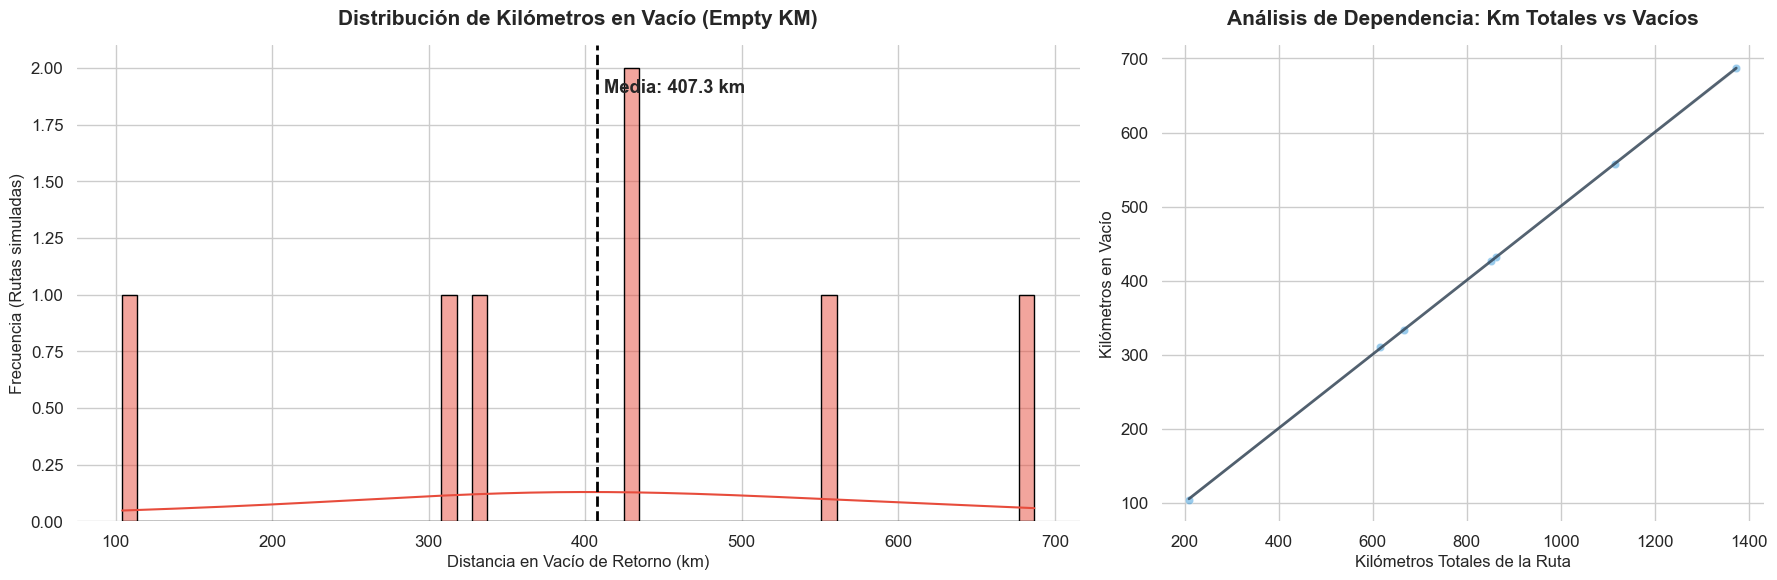

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1.2]})

# Gráfico 1: Histograma + KDE para densidad de distribución
sns.histplot(df_sim['Empty_Km'], bins=60, kde=True, color="#e74c3c", ax=ax1, edgecolor='black', linewidth=1)
ax1.set_title("Distribución de Kilómetros en Vacío (Empty KM)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Distancia en Vacío de Retorno (km)", fontsize=12)
ax1.set_ylabel("Frecuencia (Rutas simuladas)", fontsize=12)

mean_empty = df_sim['Empty_Km'].mean()
ax1.axvline(mean_empty, color='black', linestyle='dashed', linewidth=2)
ax1.text(mean_empty + 5, ax1.get_ylim()[1]*0.9, f'Media: {mean_empty:.1f} km', fontweight='bold')

# Gráfico 2: Relación dispersión (Km Total vs Empty Km)
sns.scatterplot(data=df_sim, x="Total_Km", y="Empty_Km", alpha=0.5, color="#3498db", ax=ax2, edgecolor='w')
sns.regplot(data=df_sim, x="Total_Km", y="Empty_Km", scatter=False, ax=ax2, color="#2c3e50", line_kws={"alpha":0.8, "linewidth":2})

ax2.set_title("Análisis de Dependencia: Km Totales vs Vacíos", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Kilómetros Totales de la Ruta", fontsize=12)
ax2.set_ylabel("Kilómetros en Vacío", fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

--- 
## 6. Profesional
Podemos filtrar nuestro dataset para averiguar inmediatamente cuáles son **las plantas con mayor impacto negativo** para usar como cierre de ruta.

Dejar a estas plantas como la *última entrega de la ruta* resultará en los mayores retornos en vacío.

In [21]:
worst_empty_returns = df_sim.sort_values(by='Empty_Km', ascending=False).drop_duplicates(subset=['Empty_Km']).head(5)

print(" Las 5 secuencias logísticas con mayor retorno en vacío para el último nodo:\n")
for i, row in worst_empty_returns.iterrows():
    last_plant_name = row['Ruta (Nombres)'].split('->')[-1].strip()
    print(f" Finalizar ruta en {last_plant_name:<15} -> incurre en {row['Empty_Km']:>6.1f} km km de retorno en vacío (representando un {row['Empty_Ratio_%']:>4.1f}% del recorrido total de la ruta).")


 Las 5 secuencias logísticas con mayor retorno en vacío para el último nodo:

 Finalizar ruta en Navarra         -> incurre en  686.9 km km de retorno en vacío (representando un 50.0% del recorrido total de la ruta).
 Finalizar ruta en Burgos          -> incurre en  557.7 km km de retorno en vacío (representando un 50.0% del recorrido total de la ruta).
 Finalizar ruta en Alicante        -> incurre en  431.3 km km de retorno en vacío (representando un 50.0% del recorrido total de la ruta).
 Finalizar ruta en Valencia        -> incurre en  426.7 km km de retorno en vacío (representando un 50.1% del recorrido total de la ruta).
 Finalizar ruta en Alcalá          -> incurre en  333.3 km km de retorno en vacío (representando un 50.0% del recorrido total de la ruta).
